In [2]:
# ============================================================
# SECTION 1: IMPORTS & CONFIGURATION
# ============================================================

# Data
import yfinance as yf # Download real stock data from Yahoo Finance
import pandas as pd # Data tables
import numpy as np # Math / matrix operations

# Visualization
import matplotlib.pyplot as plt # Charts in the notebook
import seaborn as sns # Charts in the notebook

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Optimization
from scipy.optimize import minimize # Optimization engine (finds best portfolio)
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [4]:
# ============================================================
# SECTION 2: DOWNLOAD STOCK DATA
# ============================================================

# --- USER INPUT (this is what the API will receive later) ---
TICKERS = ["AAPL", "MSFT", "GOOGL", "JPM", "BND", "GLD", "AMZN"]
START_DATE = "2021-01-01"
END_DATE = "2025-12-31"  # 5 years of data

print(f"📥 Downloading data for: {TICKERS}")
print(f"📅 Period: {START_DATE} to {END_DATE}\n")

# Download adjusted closing prices
raw_data = yf.download(TICKERS, start=START_DATE, end=END_DATE)
prices = raw_data['Close']

# Drop any stocks that failed to download
prices.dropna(axis=1, how='all', inplace=True)

print(f"✅ Downloaded {len(prices)} trading days of data")
print(f"📊 Stocks available: {list(prices.columns)}\n")
prices.tail()  # Show last 5 rows

📥 Downloading data for: ['AAPL', 'MSFT', 'GOOGL', 'JPM', 'BND', 'GLD', 'AMZN']
📅 Period: 2021-01-01 to 2025-12-31



[*********************100%***********************]  7 of 7 completed


✅ Downloaded 1254 trading days of data
📊 Stocks available: ['AAPL', 'AMZN', 'BND', 'GLD', 'GOOGL', 'JPM', 'MSFT']



Ticker,AAPL,AMZN,BND,GLD,GOOGL,JPM,MSFT
Date,,,,,,,
2025-12-23,272.1054,232.1400,73.2923,413.6400,314.1289,322.8143,485.7413
2025-12-24,273.5540,232.3800,73.4706,411.9300,313.8690,326.0234,486.9086
2025-12-26,273.1444,232.5200,73.4706,416.7400,313.2895,324.7754,486.5994
2025-12-29,273.5041,232.0700,73.5795,398.6000,313.3394,320.6552,485.9908
2025-12-30,272.8247,232.5300,73.5498,398.8900,313.6292,320.3284,486.3699


In [5]:
# ============================================================
# SECTION 3: FEATURE ENGINEERING
# ============================================================
# We need to create meaningful numbers (features) that 
# describe each stock's behavior. ML models learn from these.

# Daily returns (% change each day)
daily_returns = prices.pct_change().dropna()

# --- Build a feature table: one row per stock ---
features = pd.DataFrame(index=prices.columns)

# 1. Average annual return
features['annual_return'] = daily_returns.mean() * 252

# 2. Annual volatility (risk)
features['annual_volatility'] = daily_returns.std() * np.sqrt(252)

# 3. Sharpe Ratio (return per unit of risk)
features['sharpe_ratio'] = features['annual_return'] / features['annual_volatility']

# 4. Max Drawdown (worst drop from peak)
def max_drawdown(returns):
    cumulative = (1 + returns).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    return drawdown.min()

features['max_drawdown'] = daily_returns.apply(max_drawdown)

# 5. Momentum (last 6 months return)
features['momentum_6m'] = prices.iloc[-126:].pct_change(125).iloc[-1]

# 6. Skewness (is the return distribution lopsided?)
features['skewness'] = daily_returns.skew()

print("📊 Feature table built — one row per stock:\n")
print(features.round(4))

📊 Feature table built — one row per stock:

        annual_return  annual_volatility  sharpe_ratio  max_drawdown  \
Ticker                                                                 
AAPL           0.1943             0.2787        0.6970       -0.3336   
AMZN           0.1376             0.3512        0.3918       -0.5615   
BND           -0.0018             0.0601       -0.0306       -0.1797   
GLD            0.1697             0.1562        1.0866       -0.2103   
GOOGL          0.3097             0.3116        0.9941       -0.4432   
JPM            0.2454             0.2428        1.0106       -0.3877   
MSFT           0.2035             0.2572        0.7911       -0.3715   

        momentum_6m  skewness  
Ticker                         
AAPL         0.2882    0.4536  
AMZN         0.0573    0.1436  
BND          0.0339    0.0785  
GLD          0.2899   -0.2972  
GOOGL        0.7596    0.0999  
JPM          0.1183    0.1272  
MSFT        -0.0039    0.2041  


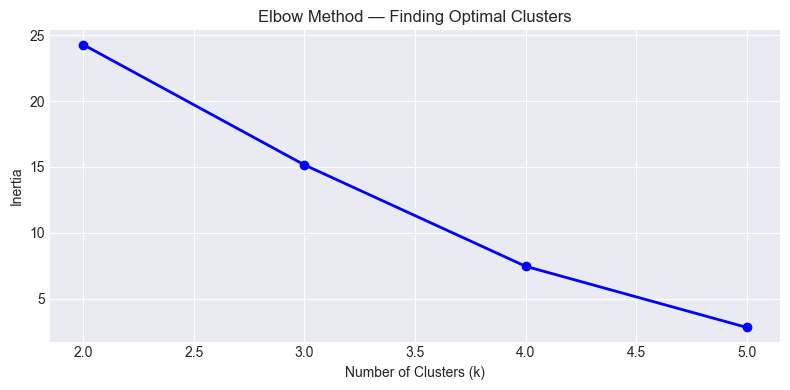

🔵 K-Means Clustering Results:

        annual_return  annual_volatility  sharpe_ratio cluster_label
Ticker                                                              
AAPL           0.1943             0.2787        0.6970      🚀 Growth
AMZN           0.1376             0.3512        0.3918      🚀 Growth
BND           -0.0018             0.0601       -0.0306  🛡️ Defensive
GLD            0.1697             0.1562        1.0866   ⚖️ Moderate
GOOGL          0.3097             0.3116        0.9941      🚀 Growth
JPM            0.2454             0.2428        1.0106      🚀 Growth
MSFT           0.2035             0.2572        0.7911      🚀 Growth


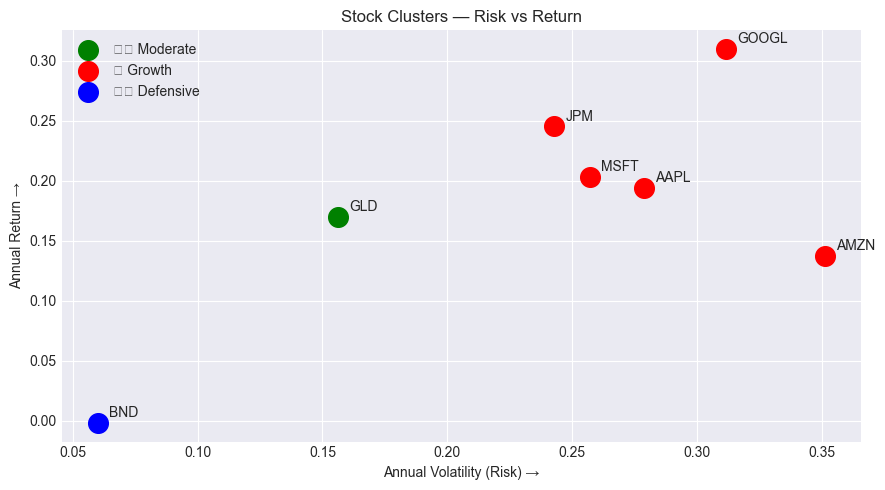

In [6]:
# ============================================================
# SECTION 4: K-MEANS CLUSTERING (UNSUPERVISED ML)
# ============================================================
# Goal: Group stocks by behavior so we ensure 
# our portfolio is diversified across different "types"

# Scale features (K-Means is distance-based, scale matters!)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# --- Find optimal number of clusters (Elbow Method) ---
inertias = []
k_range = range(2, min(6, len(TICKERS)))

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Finding Optimal Clusters')
plt.tight_layout()
plt.show()

# --- Apply K-Means with k=3 clusters ---
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
features['cluster'] = kmeans.fit_predict(features_scaled)

# Label clusters meaningfully based on their avg return/risk
cluster_summary = features.groupby('cluster')[['annual_return', 'annual_volatility']].mean()
cluster_labels = {}
sorted_clusters = cluster_summary['sharpe_ratio'].rank() if 'sharpe_ratio' in cluster_summary else cluster_summary['annual_return'].rank()

label_map = {
    cluster_summary['annual_return'].idxmax(): '🚀 Growth',
    cluster_summary['annual_volatility'].idxmin(): '🛡️ Defensive',
}
# Any remaining cluster gets labeled Moderate
for c in features['cluster'].unique():
    if c not in label_map:
        label_map[c] = '⚖️ Moderate'

features['cluster_label'] = features['cluster'].map(label_map)

print("🔵 K-Means Clustering Results:\n")
print(features[['annual_return', 'annual_volatility', 'sharpe_ratio', 'cluster_label']])

# Visualize clusters
plt.figure(figsize=(9, 5))
colors = {'🚀 Growth': 'red', '🛡️ Defensive': 'blue', '⚖️ Moderate': 'green'}
for label, group in features.groupby('cluster_label'):
    plt.scatter(group['annual_volatility'], group['annual_return'],
                label=label, s=200, color=colors.get(label, 'gray'))
    for idx, row in group.iterrows():
        plt.annotate(idx, (row['annual_volatility'], row['annual_return']),
                    textcoords="offset points", xytext=(8, 4), fontsize=10)

plt.xlabel('Annual Volatility (Risk) →')
plt.ylabel('Annual Return →')
plt.title('Stock Clusters — Risk vs Return')
plt.legend()
plt.tight_layout()
plt.show()

🌲 Training Random Forest models...



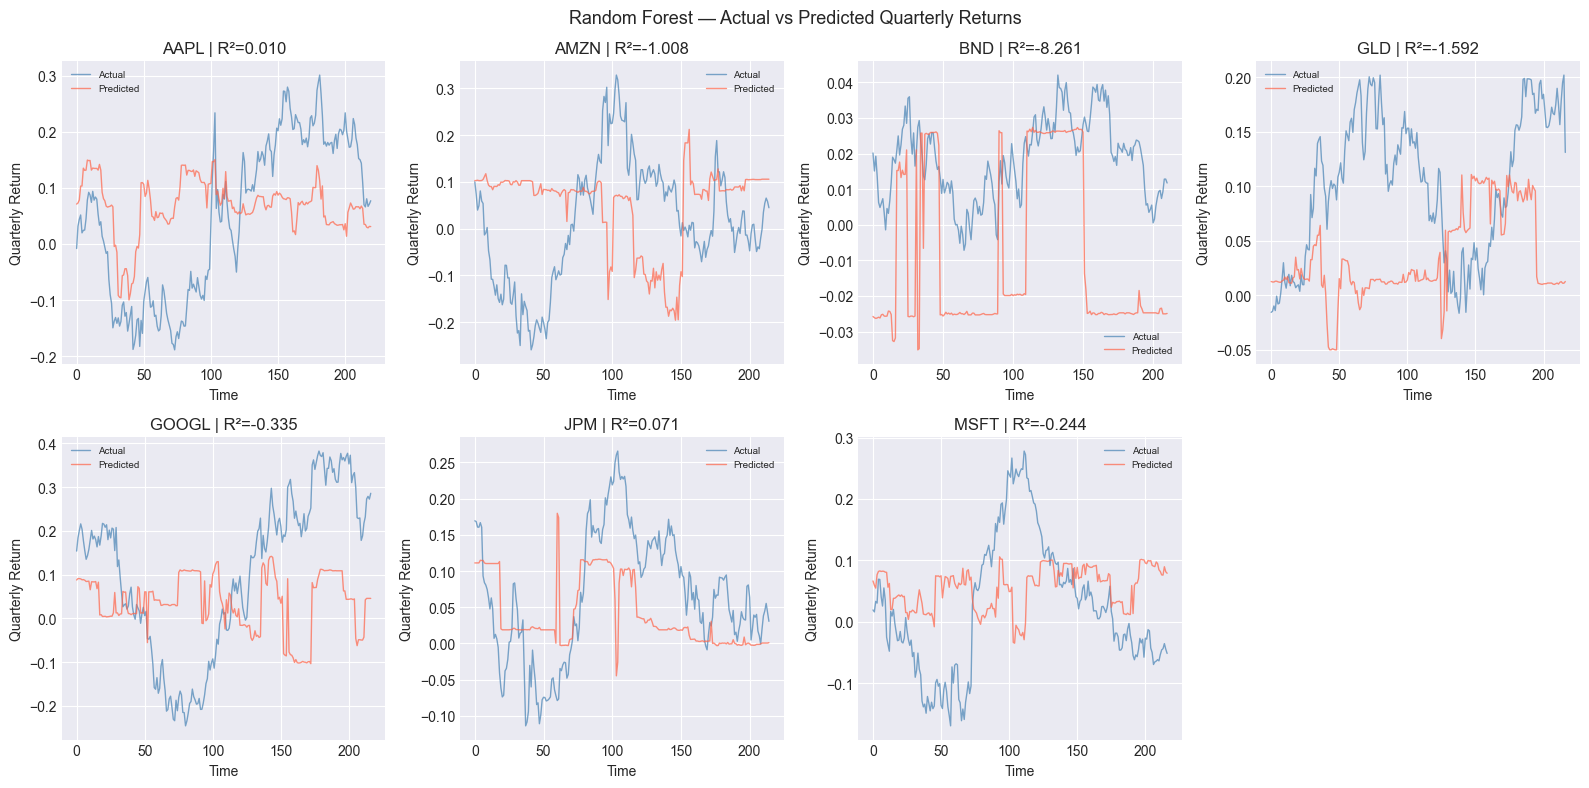


📊 Random Forest Results:

       Historical Annual Return  RF Predicted Annual Return  R² Score  \
AAPL                     0.1943                     -0.1753    0.0103   
AMZN                     0.1376                      0.8430   -1.0084   
BND                     -0.0018                      0.0399   -8.2614   
GLD                      0.1697                      0.4405   -1.5919   
GOOGL                    0.3097                      0.4432   -0.3352   
JPM                      0.2454                      0.4440    0.0714   
MSFT                     0.2035                      0.2015   -0.2442   

          Signal       Cluster  
AAPL   🔴 Bearish      🚀 Growth  
AMZN   🟢 Bullish      🚀 Growth  
BND    🟡 Neutral  🛡️ Defensive  
GLD    🟢 Bullish   ⚖️ Moderate  
GOOGL  🟢 Bullish      🚀 Growth  
JPM    🟢 Bullish      🚀 Growth  
MSFT   🟢 Bullish      🚀 Growth  


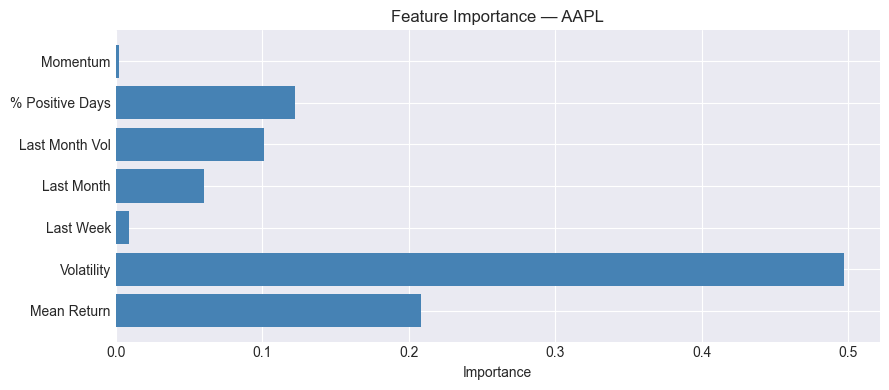


💡 Key Insight: In finance, even R²=0.05 is considered useful.
   We use predictions DIRECTIONALLY — not as exact numbers.
   A model that's right 55% of the time is valuable in trading.


In [8]:
# ============================================================
# SECTION 5: RANDOM FOREST REGRESSOR (SUPERVISED ML) - FIXED
# ============================================================
# Key changes:
# - Predict QUARTERLY returns (63 days) instead of monthly
# - Simpler, more stable features
# - Clip extreme outliers in labels
# - Use the prediction DIRECTIONALLY (up/down/neutral)
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def build_features_for_stock(stock_returns, window=60, forward=63):
    """
    window = 60 days of history as input
    forward = 63 days (1 quarter) as prediction target
    """
    X, y = [], []
    
    for i in range(window, len(stock_returns) - forward):
        window_data = stock_returns.iloc[i-window:i]
        
        # Target: cumulative return over next quarter
        future_return = (1 + stock_returns.iloc[i:i+forward]).prod() - 1
        
        row = [
            window_data.mean() * 252,            # annualized return
            window_data.std() * np.sqrt(252),     # annualized volatility
            window_data.iloc[-5:].mean() * 252,   # last week trend
            window_data.iloc[-20:].mean() * 252,  # last month trend
            window_data.iloc[-20:].std() * np.sqrt(252),  # last month vol
            (window_data > 0).sum() / window,     # % positive days
            window_data.iloc[-1] / window_data.mean() - 1,  # momentum signal
        ]
        X.append(row)
        y.append(future_return)
    
    X = np.array(X)
    y = np.array(y)
    
    # Remove extreme outliers in labels (clip at 2 std)
    y_mean, y_std = y.mean(), y.std()
    mask = np.abs(y - y_mean) < 2 * y_std
    
    return X[mask], y[mask]

# --- Train a model per stock ---
rf_predictions = {}
rf_scores = {}
rf_models = {}
rf_scalers = {}

print("🌲 Training Random Forest models...\n")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, ticker in enumerate(prices.columns):
    stock_returns = daily_returns[ticker].dropna()
    X, y = build_features_for_stock(stock_returns)
    
    if len(X) < 50:
        print(f"⚠️  {ticker}: Not enough data, skipping")
        continue
    
    # Time-series split (no shuffle!)
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    # Scale
    scaler_rf = StandardScaler()
    X_train_sc = scaler_rf.fit_transform(X_train)
    X_test_sc  = scaler_rf.transform(X_test)
    
    # Train
    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=4,        # shallower = less overfitting
        min_samples_leaf=5, # needs at least 5 samples per leaf
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train_sc, y_train)
    
    # Evaluate
    y_pred = rf.predict(X_test_sc)
    r2 = r2_score(y_test, y_pred)
    rf_scores[ticker] = r2
    rf_models[ticker] = rf
    rf_scalers[ticker] = scaler_rf
    
    # Predict future using last 60 days
    last_window = daily_returns[ticker].iloc[-60:]
    last_X = np.array([[
        last_window.mean() * 252,
        last_window.std() * np.sqrt(252),
        last_window.iloc[-5:].mean() * 252,
        last_window.iloc[-20:].mean() * 252,
        last_window.iloc[-20:].std() * np.sqrt(252),
        (last_window > 0).sum() / 60,
        last_window.iloc[-1] / last_window.mean() - 1,
    ]])
    last_X_sc = scaler_rf.transform(last_X)
    
    # Quarterly prediction → annualize it
    predicted_quarterly = rf.predict(last_X_sc)[0]
    rf_predictions[ticker] = predicted_quarterly * 4  # annualize
    
    # Plot
    if idx < len(axes):
        axes[idx].plot(y_test, label='Actual', alpha=0.7, color='steelblue', linewidth=1)
        axes[idx].plot(y_pred, label='Predicted', alpha=0.7, color='tomato', linewidth=1)
        axes[idx].set_title(f'{ticker} | R²={r2:.3f}')
        axes[idx].legend(fontsize=7)
        axes[idx].set_xlabel('Time')
        axes[idx].set_ylabel('Quarterly Return')

for i in range(len(prices.columns), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Random Forest — Actual vs Predicted Quarterly Returns', fontsize=13)
plt.tight_layout()
plt.show()

# --- Results Table ---
results_df = pd.DataFrame({
    'Historical Annual Return': features['annual_return'],
    'RF Predicted Annual Return': pd.Series(rf_predictions),
    'R² Score': pd.Series(rf_scores),
    'Signal': pd.Series(rf_predictions).apply(
        lambda x: '🟢 Bullish' if x > 0.10 else ('🔴 Bearish' if x < 0 else '🟡 Neutral')
    ),
    'Cluster': features['cluster_label']
}).round(4)

print("\n📊 Random Forest Results:\n")
print(results_df)

# --- Feature Importance (for one stock as example) ---
sample_ticker = list(rf_models.keys())[0]
importances = rf_models[sample_ticker].feature_importances_
feat_names = ['Mean Return', 'Volatility', 'Last Week', 
              'Last Month', 'Last Month Vol', '% Positive Days', 'Momentum']

plt.figure(figsize=(9, 4))
bars = plt.barh(feat_names, importances, color='steelblue')
plt.xlabel('Importance')
plt.title(f'Feature Importance — {sample_ticker}')
plt.tight_layout()
plt.show()

print(f"\n💡 Key Insight: In finance, even R²=0.05 is considered useful.")
print(f"   We use predictions DIRECTIONALLY — not as exact numbers.")
print(f"   A model that's right 55% of the time is valuable in trading.")

🔴 Building MLP Neural Network...

📊 Dataset: 1138 samples, 29 features

🧠 MLP Performance:
   R² Score : -2.7944
   MSE      : 0.063875


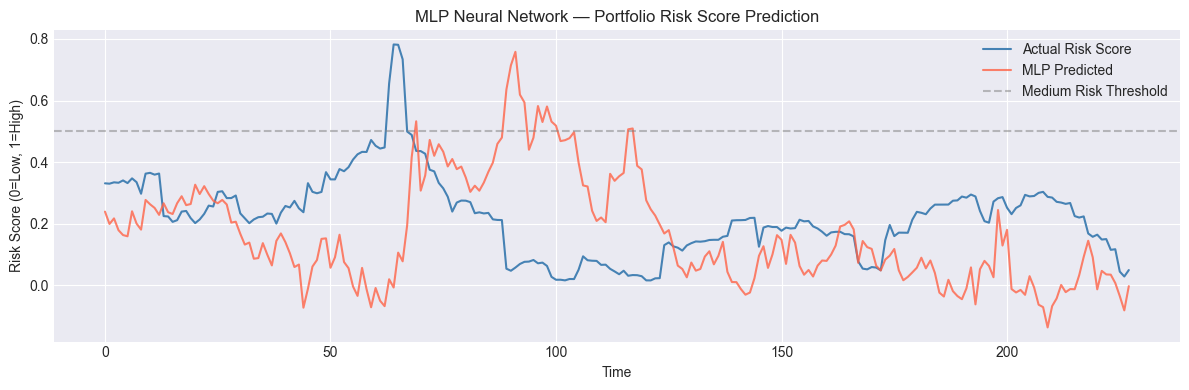

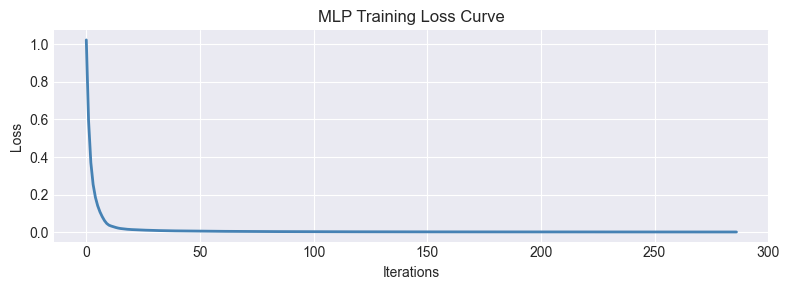


🎯 Current Portfolio Risk Assessment:
   Risk Score : 0.2205 / 1.0
   Risk Level : 🟢 LOW RISK

💡 This score will be used to adjust the optimizer's
   risk tolerance in the next section.


In [9]:
# ============================================================
# SECTION 6: MLP NEURAL NETWORK
# ============================================================
# Goal: Assess the OVERALL RISK LEVEL of a portfolio
# 
# HOW IT WORKS:
# - Input: all 7 stocks' features combined (portfolio view)
# - Output: Risk Score (0 = low risk, 1 = high risk)
# - We train it on rolling portfolio volatility as the label
# - This gives us a single "portfolio health" number
# ============================================================

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("🔴 Building MLP Neural Network...\n")

# --- Step 6.1: Build Portfolio-Level Features ---
# Instead of per-stock, we look at the WHOLE portfolio at once

def build_portfolio_features(returns_df, window=60, forward=21):
    """
    Each row = one time window describing the whole portfolio
    Label = realized portfolio volatility over next 21 days
    """
    X, y = [], []
    tickers = returns_df.columns.tolist()
    
    for i in range(window, len(returns_df) - forward):
        window_data = returns_df.iloc[i-window:i]
        future_data = returns_df.iloc[i:i+forward]
        
        row = []
        for ticker in tickers:
            col = window_data[ticker]
            row.extend([
                col.mean() * 252,           # annualized return
                col.std() * np.sqrt(252),   # annualized vol
                (col > 0).sum() / window,   # % positive days
                col.iloc[-5:].mean() * 252, # recent trend
            ])
        
        # Correlation bonus feature: avg pairwise correlation
        corr_matrix = window_data.corr()
        upper_triangle = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        avg_corr = upper_triangle.stack().mean()
        row.append(avg_corr)
        
        # Label: equal-weight portfolio volatility next 21 days
        equal_weight_returns = future_data.mean(axis=1)
        portfolio_vol = equal_weight_returns.std() * np.sqrt(252)
        
        X.append(row)
        y.append(portfolio_vol)
    
    return np.array(X), np.array(y)

# Build dataset
X_port, y_port = build_portfolio_features(daily_returns)

# Remove outliers
y_mean, y_std = y_port.mean(), y_port.std()
mask = np.abs(y_port - y_mean) < 2.5 * y_std
X_port, y_port = X_port[mask], y_port[mask]

# Normalize labels to 0-1 (Risk Score)
y_min, y_max = y_port.min(), y_port.max()
y_normalized = (y_port - y_min) / (y_max - y_min)

print(f"📊 Dataset: {len(X_port)} samples, {X_port.shape[1]} features")

# --- Step 6.2: Train/Test Split ---
split = int(len(X_port) * 0.8)
X_train, X_test = X_port[:split], X_port[split:]
y_train, y_test = y_normalized[:split], y_normalized[split:]

# Scale
scaler_mlp = StandardScaler()
X_train_sc = scaler_mlp.fit_transform(X_train)
X_test_sc  = scaler_mlp.transform(X_test)

# --- Step 6.3: Build & Train MLP ---
# Architecture: 4 layers (29 inputs → 64 → 32 → 16 → 1 output)
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20
)

mlp.fit(X_train_sc, y_train)

# --- Step 6.4: Evaluate ---
y_pred_test = mlp.predict(X_test_sc)
r2 = r2_score(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)

print(f"\n🧠 MLP Performance:")
print(f"   R² Score : {r2:.4f}")
print(f"   MSE      : {mse:.6f}")

# Plot actual vs predicted risk score
plt.figure(figsize=(12, 4))
plt.plot(y_test, label='Actual Risk Score', color='steelblue', linewidth=1.5)
plt.plot(y_pred_test, label='MLP Predicted', color='tomato', linewidth=1.5, alpha=0.8)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Medium Risk Threshold')
plt.ylabel('Risk Score (0=Low, 1=High)')
plt.xlabel('Time')
plt.title('MLP Neural Network — Portfolio Risk Score Prediction')
plt.legend()
plt.tight_layout()
plt.show()

# Training loss curve
plt.figure(figsize=(8, 3))
plt.plot(mlp.loss_curve_, color='steelblue', linewidth=2)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('MLP Training Loss Curve')
plt.tight_layout()
plt.show()

# --- Step 6.5: Predict CURRENT Risk Score ---
# Use the most recent 60 days as input
last_window = daily_returns.iloc[-60:]
last_X = []
for ticker in daily_returns.columns:
    col = last_window[ticker]
    last_X.extend([
        col.mean() * 252,
        col.std() * np.sqrt(252),
        (col > 0).sum() / 60,
        col.iloc[-5:].mean() * 252,
    ])

corr_now = last_window.corr()
upper = corr_now.where(np.triu(np.ones(corr_now.shape), k=1).astype(bool))
last_X.append(upper.stack().mean())

last_X_sc = scaler_mlp.transform([last_X])
current_risk_score = mlp.predict(last_X_sc)[0]
current_risk_score = float(np.clip(current_risk_score, 0, 1))

# Label the risk
if current_risk_score < 0.35:
    risk_label = "🟢 LOW RISK"
elif current_risk_score < 0.65:
    risk_label = "🟡 MEDIUM RISK"
else:
    risk_label = "🔴 HIGH RISK"

print(f"\n🎯 Current Portfolio Risk Assessment:")
print(f"   Risk Score : {current_risk_score:.4f} / 1.0")
print(f"   Risk Level : {risk_label}")
print(f"\n💡 This score will be used to adjust the optimizer's")
print(f"   risk tolerance in the next section.")

# Store for later use
mlp_risk_score = current_risk_score

📊 Expected Returns (blended RF + Historical):
   AAPL  : 0.1931 (19.31%)
   AMZN  : 0.1376 (13.76%)
   BND   : -0.0018 (-0.18%)
   GLD   : 0.1697 (16.97%)
   GOOGL : 0.3097 (30.97%)
   JPM   : 0.2497 (24.97%)
   MSFT  : 0.2035 (20.35%)

🧠 MLP Risk Score  : 0.2205 → Growth mode
   Max weight/stock: 40%
   Min defensive   : 2%

🔵 Clusters:
   Defensive : ['BND']
   Moderate  : ['GLD']
   Growth    : ['AAPL', 'AMZN', 'GOOGL', 'JPM', 'MSFT']

⚙️  Running Monte Carlo (8,000 portfolios)...

✅ Optimization complete!
   Max Sharpe  → Return: 22.03%  Vol: 14.35%  Sharpe: 1.187
   Min Variance→ Return: 11.63%  Vol: 8.64%  Sharpe: 0.768


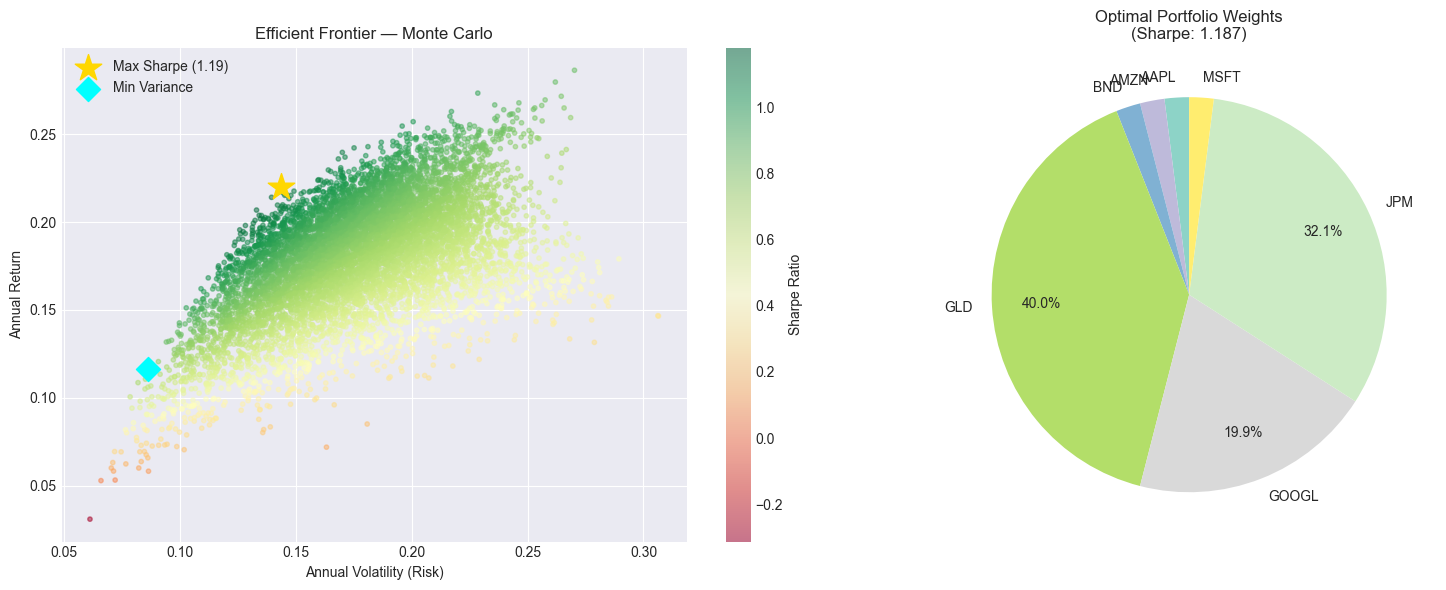


📊 Optimal Portfolio Weights:
Ticker  Optimal Weight  Expected Return      Cluster
   GLD          0.4000           0.1697  ⚖️ Moderate
   JPM          0.3208           0.2497     🚀 Growth
 GOOGL          0.1992           0.3097     🚀 Growth
  AAPL          0.0200           0.1931     🚀 Growth
  AMZN          0.0200           0.1376     🚀 Growth
   BND          0.0200          -0.0018 🛡️ Defensive
  MSFT          0.0200           0.2035     🚀 Growth


In [10]:
# ============================================================
# SECTION 7: MPT OPTIMIZER + REBALANCING ENGINE
# ============================================================
# This is where all 3 ML models feed into the final output:
#
# K-Means  → tells us cluster diversity constraints
# RF       → gives us predicted returns per stock  
# MLP      → gives us current risk score
# MPT      → finds mathematically optimal weights
# Engine   → compares optimal vs current portfolio
# ============================================================

from scipy.optimize import minimize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── 7.1  INPUTS FROM ML MODELS ──────────────────────────────

# Predicted returns from Random Forest (annualized)
# Fall back to historical if RF prediction looks unreliable
def blend_returns(ticker, rf_pred, hist_return, r2_score, blend=0.3):
    """
    If R² is low, trust historical more than RF prediction.
    blend=0.3 means 30% RF + 70% historical when R²<0
    """
    weight = max(0.0, min(1.0, r2_score)) * blend
    return weight * rf_pred + (1 - weight) * hist_return

tickers = list(prices.columns)

blended_returns = {}
for t in tickers:
    rf_pred  = rf_predictions.get(t, features.loc[t, 'annual_return'])
    hist_ret = features.loc[t, 'annual_return']
    r2       = rf_scores.get(t, 0)
    blended_returns[t] = blend_returns(t, rf_pred, hist_ret, r2)

expected_returns = np.array([blended_returns[t] for t in tickers])

print("📊 Expected Returns (blended RF + Historical):")
for t, r in zip(tickers, expected_returns):
    print(f"   {t:6s}: {r:.4f} ({r*100:.2f}%)")

# Covariance matrix from historical daily returns
cov_matrix = daily_returns[tickers].cov() * 252  # annualized

# Risk score from MLP (0=low risk, 1=high risk)
risk_score = mlp_risk_score
print(f"\n🧠 MLP Risk Score  : {risk_score:.4f} → {'Conservative' if risk_score>0.65 else 'Balanced' if risk_score>0.35 else 'Growth'} mode")

# ── 7.2  RISK-ADJUSTED CONSTRAINTS ──────────────────────────
# MLP risk score shifts how aggressive the optimizer is

# Base max weight per stock
if risk_score < 0.35:      # LOW risk → allow up to 40% in one stock
    max_weight = 0.40
elif risk_score < 0.65:    # MEDIUM risk → cap at 30%
    max_weight = 0.30
else:                      # HIGH risk → cap at 20%, push to bonds/gold
    max_weight = 0.20

# Minimum weight for defensive assets when risk is high
min_defensive = 0.10 if risk_score > 0.5 else 0.02

print(f"   Max weight/stock: {max_weight:.0%}")
print(f"   Min defensive   : {min_defensive:.0%}")

# ── 7.3  CLUSTER DIVERSITY CONSTRAINT ───────────────────────
# Ensure at least one stock from each cluster is included
cluster_map = features['cluster_label'].to_dict()
defensive_tickers = [t for t in tickers if cluster_map.get(t,'') == '🛡️ Defensive']
moderate_tickers  = [t for t in tickers if cluster_map.get(t,'') == '⚖️ Moderate']
growth_tickers    = [t for t in tickers if cluster_map.get(t,'') == '🚀 Growth']

print(f"\n🔵 Clusters:")
print(f"   Defensive : {defensive_tickers}")
print(f"   Moderate  : {moderate_tickers}")
print(f"   Growth    : {growth_tickers}")

# ── 7.4  PORTFOLIO METRICS ───────────────────────────────────
def portfolio_performance(weights, expected_returns, cov_matrix, risk_free=0.05):
    ret = np.dot(weights, expected_returns)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe = (ret - risk_free) / vol
    return ret, vol, sharpe

def neg_sharpe(weights):
    _, _, sharpe = portfolio_performance(weights, expected_returns, cov_matrix)
    return -sharpe

# ── 7.5  MONTE CARLO SIMULATION ─────────────────────────────
n_portfolios = 8000
n_assets = len(tickers)
mc_returns, mc_vols, mc_sharpes, mc_weights = [], [], [], []

print(f"\n⚙️  Running Monte Carlo ({n_portfolios:,} portfolios)...")

for _ in range(n_portfolios):
    w = np.random.dirichlet(np.ones(n_assets))
    r, v, s = portfolio_performance(w, expected_returns, cov_matrix)
    mc_returns.append(r)
    mc_vols.append(v)
    mc_sharpes.append(s)
    mc_weights.append(w)

mc_returns  = np.array(mc_returns)
mc_vols     = np.array(mc_vols)
mc_sharpes  = np.array(mc_sharpes)

# ── 7.6  SCIPY OPTIMIZATION ─────────────────────────────────
constraints = [
    {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},  # weights sum to 1
]

bounds = []
for t in tickers:
    if t in defensive_tickers:
        bounds.append((min_defensive, max_weight))
    else:
        bounds.append((0.02, max_weight))

# Max Sharpe portfolio
w0 = np.ones(n_assets) / n_assets
result = minimize(neg_sharpe, w0, method='SLSQP',
                  bounds=bounds, constraints=constraints,
                  options={'maxiter': 1000, 'ftol': 1e-9})

opt_weights  = result.x
opt_ret, opt_vol, opt_sharpe = portfolio_performance(opt_weights, expected_returns, cov_matrix)

# Min Variance portfolio
def portfolio_variance(w):
    return np.dot(w.T, np.dot(cov_matrix, w))

result_minvar = minimize(portfolio_variance, w0, method='SLSQP',
                         bounds=bounds, constraints=constraints)
mv_weights = result_minvar.x
mv_ret, mv_vol, mv_sharpe = portfolio_performance(mv_weights, expected_returns, cov_matrix)

print(f"\n✅ Optimization complete!")
print(f"   Max Sharpe  → Return: {opt_ret:.2%}  Vol: {opt_vol:.2%}  Sharpe: {opt_sharpe:.3f}")
print(f"   Min Variance→ Return: {mv_ret:.2%}  Vol: {mv_vol:.2%}  Sharpe: {mv_sharpe:.3f}")

# ── 7.7  EFFICIENT FRONTIER CHART ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Efficient Frontier
sc = axes[0].scatter(mc_vols, mc_returns, c=mc_sharpes,
                     cmap='RdYlGn', alpha=0.5, s=10)
plt.colorbar(sc, ax=axes[0], label='Sharpe Ratio')

axes[0].scatter(opt_vol, opt_ret, marker='*', color='gold',
                s=400, zorder=5, label=f'Max Sharpe ({opt_sharpe:.2f})')
axes[0].scatter(mv_vol, mv_ret, marker='D', color='cyan',
                s=150, zorder=5, label=f'Min Variance')

axes[0].set_xlabel('Annual Volatility (Risk)')
axes[0].set_ylabel('Annual Return')
axes[0].set_title('Efficient Frontier — Monte Carlo')
axes[0].legend()

# Right: Optimal Weights Pie
colors = plt.cm.Set3(np.linspace(0, 1, n_assets))
wedges, texts, autotexts = axes[1].pie(
    opt_weights,
    labels=tickers,
    autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
    colors=colors,
    startangle=90,
    pctdistance=0.75
)
axes[1].set_title(f'Optimal Portfolio Weights\n(Sharpe: {opt_sharpe:.3f})')

plt.tight_layout()
plt.show()

# ── 7.8  WEIGHTS TABLE ───────────────────────────────────────
weights_df = pd.DataFrame({
    'Ticker'          : tickers,
    'Optimal Weight'  : opt_weights,
    'Expected Return' : expected_returns,
    'Cluster'         : [cluster_map.get(t,'') for t in tickers]
}).sort_values('Optimal Weight', ascending=False)

print("\n📊 Optimal Portfolio Weights:")
print(weights_df.to_string(index=False))


🔄 PORTFOLIO REBALANCING ENGINE

💰 Total Portfolio Value: $11,500.00

Stock      Cluster RF Signal Current $ Current % Optimal % Target $ Trade $ Action
 AAPL     🚀 Growth         🔴    $5,000     43.5%      2.0%     $230  -4,770 🔴 SELL
 AMZN     🚀 Growth         🟢        $0      0.0%      2.0%     $230    +230  🟢 BUY
  BND 🛡️ Defensive         🟡      $500      4.3%      2.0%     $230    -270 🔴 SELL
  GLD  ⚖️ Moderate         🟢        $0      0.0%     40.0%   $4,600  +4,600  🟢 BUY
GOOGL     🚀 Growth         🟢    $3,000     26.1%     19.9%   $2,291    -709 🔴 SELL
  JPM     🚀 Growth         🟢    $1,000      8.7%     32.1%   $3,689  +2,689  🟢 BUY
 MSFT     🚀 Growth         🟢    $2,000     17.4%      2.0%     $230  -1,770 🔴 SELL

──────────────────────────────────────────────────
📈 PORTFOLIO IMPROVEMENT SUMMARY
──────────────────────────────────────────────────
                  Current    Optimal    Change
  Annual Return : 22.18%      22.03%    -0.15%
  Volatility    : 22.44%      14.35% 

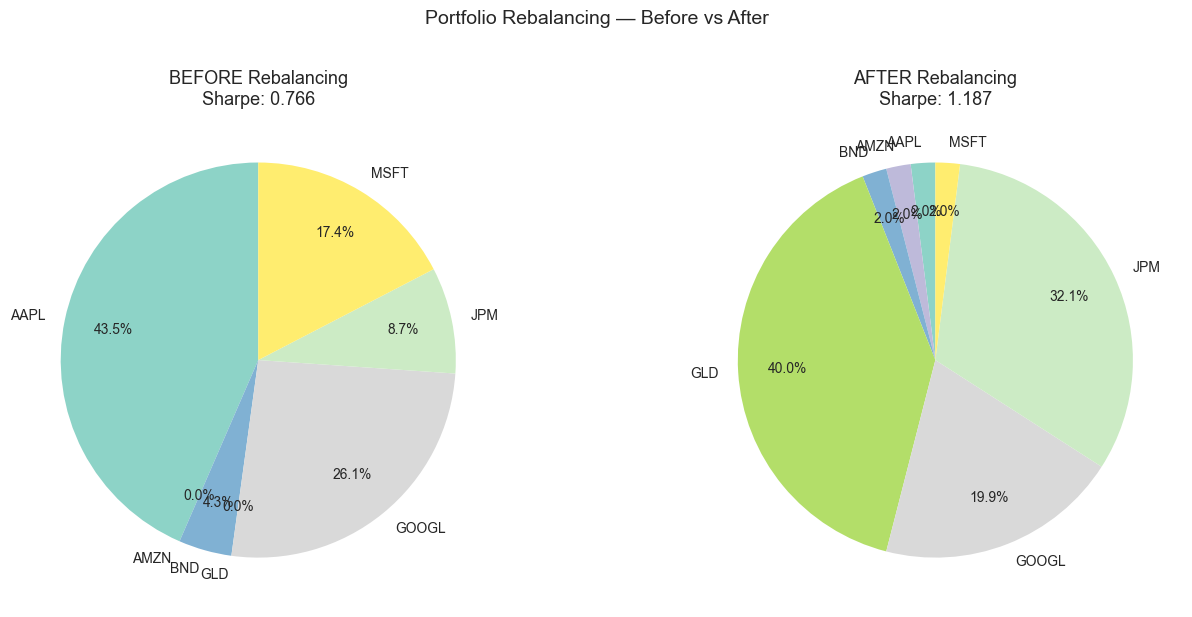


✅ Section 7 complete! The notebook brain is fully built.
   Next step: wrap this logic into a FastAPI application.


In [11]:
# ── 7.9  REBALANCING ENGINE ──────────────────────────────────
print("\n" + "="*60)
print("🔄 PORTFOLIO REBALANCING ENGINE")
print("="*60)

# --- USER'S CURRENT PORTFOLIO (example — will come from UI) ---
current_holdings = {
    "AAPL" : 5000,
    "MSFT" : 2000,
    "GOOGL": 3000,
    "JPM"  : 1000,
    "BND"  : 500,
    "GLD"  : 0,
    "AMZN" : 0
}

total_value = sum(current_holdings.values())
print(f"\n💰 Total Portfolio Value: ${total_value:,.2f}\n")

# Current weights
current_weights = {t: current_holdings.get(t, 0) / total_value for t in tickers}

# Optimal weights from optimizer
optimal_weights = {t: w for t, w in zip(tickers, opt_weights)}

# Current portfolio metrics
curr_w = np.array([current_weights[t] for t in tickers])
curr_ret, curr_vol, curr_sharpe = portfolio_performance(curr_w, expected_returns, cov_matrix)

# Build rebalancing table
rebalance_data = []
for t in tickers:
    curr_pct   = current_weights[t]
    opt_pct    = optimal_weights[t]
    curr_val   = current_holdings.get(t, 0)
    opt_val    = opt_pct * total_value
    difference = opt_val - curr_val
    
    if difference > 50:
        action = '🟢 BUY'
    elif difference < -50:
        action = '🔴 SELL'
    else:
        action = '🟡 HOLD'
    
    rebalance_data.append({
        'Stock'        : t,
        'Cluster'      : cluster_map.get(t,''),
        'RF Signal'    : '🟢' if rf_predictions.get(t,0) > 0.10 else ('🔴' if rf_predictions.get(t,0) < 0 else '🟡'),
        'Current $'    : f'${curr_val:,.0f}',
        'Current %'    : f'{curr_pct:.1%}',
        'Optimal %'    : f'{opt_pct:.1%}',
        'Target $'     : f'${opt_val:,.0f}',
        'Trade $'      : f'{"+" if difference>0 else ""}{difference:,.0f}',
        'Action'       : action
    })

rebalance_df = pd.DataFrame(rebalance_data)
print(rebalance_df.to_string(index=False))

# Portfolio improvement summary
print(f"\n{'─'*50}")
print(f"📈 PORTFOLIO IMPROVEMENT SUMMARY")
print(f"{'─'*50}")
print(f"                  Current    Optimal    Change")
print(f"  Annual Return : {curr_ret:.2%}      {opt_ret:.2%}    {(opt_ret-curr_ret):+.2%}")
print(f"  Volatility    : {curr_vol:.2%}      {opt_vol:.2%}    {(opt_vol-curr_vol):+.2%}")
print(f"  Sharpe Ratio  : {curr_sharpe:.3f}       {opt_sharpe:.3f}    {(opt_sharpe-curr_sharpe):+.3f}")
print(f"  MLP Risk Score: {risk_score:.4f} ({'🟢 LOW' if risk_score<0.35 else '🟡 MED' if risk_score<0.65 else '🔴 HIGH'})")
print(f"{'─'*50}")

# ── 7.10 BEFORE vs AFTER PIE CHARTS ─────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = plt.cm.Set3(np.linspace(0, 1, n_assets))

# Before
before_vals = [current_holdings.get(t, 0) for t in tickers]
ax1.pie(before_vals, labels=tickers, autopct='%1.1f%%',
        colors=colors, startangle=90, pctdistance=0.75)
ax1.set_title(f'BEFORE Rebalancing\nSharpe: {curr_sharpe:.3f}', fontsize=13)

# After
after_vals = [opt_weights[i] * total_value for i, _ in enumerate(tickers)]
ax2.pie(after_vals, labels=tickers, autopct='%1.1f%%',
        colors=colors, startangle=90, pctdistance=0.75)
ax2.set_title(f'AFTER Rebalancing\nSharpe: {opt_sharpe:.3f}', fontsize=13)

plt.suptitle('Portfolio Rebalancing — Before vs After', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n✅ Section 7 complete! The notebook brain is fully built.")
print("   Next step: wrap this logic into a FastAPI application.")